# TCR specificity analysis — grouping receptors by their antigen

Two T cells that recognise the **same peptide-MHC** very often carry **similar
T-cell receptors**. Antigen contact is dominated by the hyper-variable **CDR3**
loop of the receptor, so TCRs against a shared epitope tend to converge on a
shared CDR3 *motif* (a few conserved residues) and a shared V/J gene - even when
they arose independently in different people. **TCR-specificity analysis** is the
set of methods that exploit this convergence: instead of grouping receptors by
*clonal descent* (who-came-from-whom - that is `ov.airr`'s clonotype layer), it
groups them by **predicted antigen**.

This tutorial walks the complete `ov.airr` TCR-specificity toolkit:

| Step | Function | What it does |
|---|---|---|
| Distance | `ov.airr.tcrdist` | TCRdist position-weighted multi-CDR-loop metric |
| Distance clustering | `ov.airr.tcr_neighbors`, `ov.airr.tcr_cluster` | fixed-radius / hierarchical clusters on the TCRdist graph |
| Fast clustering | `ov.airr.giana_cluster`, `ov.airr.clustcr_cluster` | near-linear-time CDR3-encoding clustering |
| Specificity groups | `ov.airr.specificity_groups` | GLIPH2 motif + global convergence groups |
| Meta-clonotypes | `ov.airr.meta_clonotypes` | centroid TCR + adaptive radius + CDR3 motif |
| Motif logos | `ov.airr.cdr3_logo`, `ov.airr.cdr3_logo_background` | CDR3 sequence-logo visualisation |
| Database annotation | `ov.airr.annotate_antigen` | match CDR3s against VDJdb / McPAS / IEDB |
| Innate-like cells | `ov.airr.detect_invariant` | MAIT / iNKT detection by invariant V/J genes |

## Why this dataset is special - built-in ground truth

We use the **10x Genomics dCODE-Dextramer** experiment - CD8+ T cells from a
healthy donor stained with a panel of **pMHC dextramers**. A dextramer is a
multimerised peptide-MHC reagent: a cell that **binds** a given dextramer is, by
construction, **specific for that peptide**. So every cell carries a
*ground-truth antigen label* (`obs['antigen_epitope']`) - Influenza-MP
(`GILGFVFTL`), EBV (`AVFDRKSDAK`, `KLGGALQAK` ...), CMV and others.

That lets us do something most TCR-specificity tutorials cannot: **validate**.
For every clustering / grouping method below we measure *purity* - do the TCRs
that a method puts together actually share the same dextramer antigen? - and
quantify how faithfully each method recovers true antigen specificity.


## 0. Setup

`ov.airr` is the immune-repertoire suite of omicverse. The TCR-specificity layer
is **AnnData-native and dependency-light**: the TCRdist / clustering core is pure
numpy, and the optional GLIPH2 (`pygliph`) and logo (`logomaker`) backends import
lazily. Nothing here needs an external single-cell library - we stay inside
`ov.*` throughout.

In [1]:
import omicverse as ov
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ov.plot_set()
print("omicverse", ov.__version__)

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
🚫 No GPU devices found (CUDA/MPS/ROCm/XPU)

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.

omicverse 2.2.1rc1


## 1. Load and inspect the antigen-labelled repertoire

`ov.datasets.airr_tcr_antigen()` returns the dextramer dataset as a single
AnnData - gene expression in `.X`, and the per-cell TCR chains in `.obs` under
the `ov.airr` schema (`VDJ_1_*` = the **beta** chain, `VJ_1_*` = the **alpha**
chain). The dextramer-derived specificity call lives alongside it in
`obs['antigen']` / `antigen_epitope` / `antigen_species` / `is_antigen_bound`.

In [2]:
adata = ov.datasets.airr_tcr_antigen()
print(f"matrix      : {adata.n_obs} cells x {adata.n_vars} genes")
print(f"beta CDR3   : {adata.obs['VDJ_1_junction_aa'].notna().sum()} cells")
print(f"alpha CDR3  : {adata.obs['VJ_1_junction_aa'].notna().sum()} cells")
print(f"antigen-bound: {(adata.obs['is_antigen_bound'].astype(str)=='True').sum()} cells")
adata

🔍 Downloading data to ./data/tcr_antigen_dextramer.h5ad
⚠️ File ./data/tcr_antigen_dextramer.h5ad already exists


matrix      : 6500 cells x 2012 genes
beta CDR3   : 6500 cells
alpha CDR3  : 6500 cells
antigen-bound: 5642 cells


AnnData object with n_obs × n_vars = 6500 × 2012
    obs: 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'leiden', 'antigen', 'antigen_hla', 'antigen_epitope', 'antigen_species', 'is_antigen_bound', 'has_ir', 'receptor_type', 'VJ_1_v_gene', 'VJ_1_d_gene', 'VJ_1_j_gene', 'VJ_1_c_gene', 'VJ_1_junction', 'VJ_1_junction_aa', 'VJ_1_locus', 'VJ_1_duplicate_count', 'VJ_1_productive', 'VJ_2_v_gene', 'VJ_2_d_gene', 'VJ_2_j_gene', 'VJ_2_c_gene', 'VJ_2_junction', 'VJ_2_junction_aa', 'VJ_2_locus', 'VJ_2_duplicate_count', 'VJ_2_productive', 'VDJ_1_v_gene', 'VDJ_1_d_gene', 'VDJ_1_j_gene', 'VDJ_1_c_gene', 'VDJ_1_junction', 'VDJ_1_junction_aa', 'VDJ_1_locus', 'VDJ_1_duplicate_count', 'VDJ_1_productive', 'VDJ_2_v_gene', 'VDJ_2_d_gene', 'VDJ_2_j_gene', 'VDJ_2_c_gene', 'VDJ_2_junction', 'VDJ_2_junction_aa', 'VDJ_2_locus', 'VDJ_2_duplicate_count', 'VDJ_2_productive', 'donor'
    var: 'gene_ids', 

The dataset is **6,500 CD8+ T cells**, every one carrying a paired
alpha/beta TCR. Let us look at the antigen composition - the ground truth we will
validate against.

In [3]:
sp = adata.obs['antigen_species'].value_counts()
print("antigen species (dextramer call):")
print(sp.to_string())
print()
epi = adata.obs['antigen_epitope'].value_counts().head(6)
print("top epitopes:")
print(epi.to_string())

antigen species (dextramer call):
antigen_species
EBV                    2945
CMV                    1215
Influenza              1200
unbound                 858
Cancer                  218
HIV                      20
HTLV-1                   12
Y                        10
HPV                       9
Ca2-indepen-Plip-A2       8
WT-1                      5

top epitopes:
antigen_epitope
AVFDRKSDAK    1200
IVTDFSVIK     1200
GILGFVFTL     1200
KLGGALQAK     1200
unbound        858
RAKFKQLL       233


Four epitopes dominate (each capped at ~1,200 cells in this tutorial
subset): Influenza-MP `GILGFVFTL`, and three EBV epitopes (`AVFDRKSDAK`,
`KLGGALQAK`, `IVTDFSVIK`), plus ~860 *unbound* cells (no dextramer - a built-in
negative control) and a long tail of rare specificities.

TCRdist and GLIPH2 are O(n^2) in the repertoire size, so for an interactive
tutorial we take a **stratified 1,200-cell subsample**. We keep the full object
for context and carry a `subset` for the specificity work.

In [4]:
np.random.seed(0)
sub_idx = np.random.choice(adata.n_obs, 1200, replace=False)
subset = adata[sub_idx].copy()
print(f"working subset: {subset.n_obs} cells")
print(subset.obs['antigen_species'].value_counts().head(5).to_string())

working subset: 1200 cells
antigen_species
EBV          522
CMV          222
Influenza    219
unbound      183
Cancer        44


Several `ov.airr` functions normalise their input by cleaning the CDR3
strings, which silently drops a few cells with a malformed beta junction.
To validate cluster purity later we must align the **ground-truth labels** to the
exact same set of surviving rows - so `ov.airr.usable_cdr3_mask` builds the
boolean mask of cells with a usable CDR3 (using the same cleaning rule
`ov.airr` applies internally), and we slice an aligned truth vector once.

In [5]:
keep = ov.airr.usable_cdr3_mask(subset, chain='beta')
truth_epi = subset.obs.loc[keep, 'antigen_epitope'].astype(str).to_numpy()
truth_sp = subset.obs.loc[keep, 'antigen_species'].astype(str).to_numpy()
print(f"{keep.sum()} cells carry a usable beta CDR3 (aligned ground truth)")

1176 cells carry a usable beta CDR3 (aligned ground truth)


## 2. TCRdist - the position-weighted TCR distance

**TCRdist** (Dash *et al.*, *Nature* 2017) scores how different two TCRs are as a
**sum of BLOSUM62-derived substitution distances** over the antigen-contacting
CDR loops - CDR1, CDR2, CDR2.5 and CDR3 - with the hyper-variable **CDR3
up-weighted** (`cdr3_weight=3`) and an additive `gap_penalty` for length
mismatches. The germline CDR1/2/2.5 contribution is captured by V-gene identity.
The result is an `(n, n)` distance matrix in which **small values = likely the
same specificity**.

`ov.airr.tcrdist` returns `(D, df)` - the matrix `D` and the normalised
clonotype frame `df` whose row order matches `D`.

In [6]:
D, tcr_df = ov.airr.tcrdist(subset, chain='beta', cdr3_weight=3.0)
print(f"TCRdist matrix : {D.shape}")
print(f"clonotype frame: {tcr_df.shape[0]} TCRs, columns {list(tcr_df.columns)}")
iu = np.triu_indices_from(D, k=1)
print(f"distance range : {D[iu].min():.0f} - {D[iu].max():.0f}, "
      f"median {np.median(D[iu]):.0f}")

TCRdist matrix : (1176, 1176)
clonotype frame: 1176 TCRs, columns ['cdr3_b_aa', 'v_b', 'j_b', 'cdr3_a_aa', 'v_a', 'j_a', 'count']
distance range : 0 - 229, median 103


The distance distribution is the key diagnostic. If antigen-specific
structure exists, the histogram is **bimodal**: a small left peak of
near-identical TCRs (within-specificity pairs) on top of a broad bulk of
unrelated pairs. We compare the full pairwise distribution against the
distribution restricted to **same-epitope** pairs.

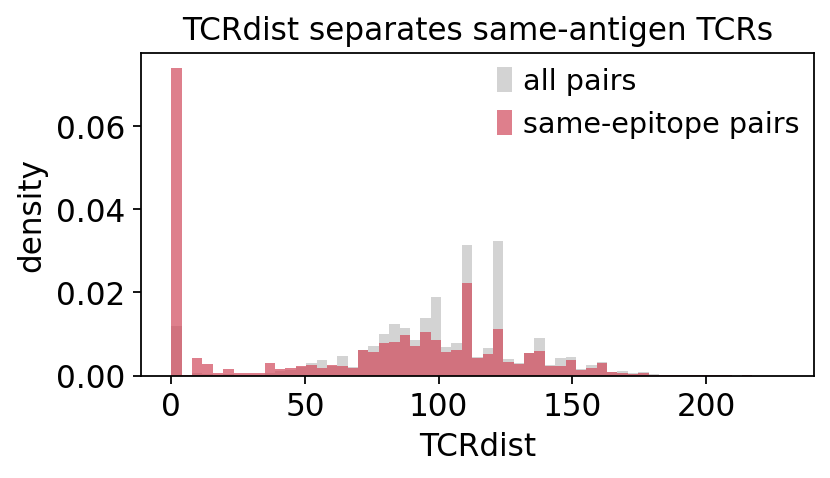

In [7]:
same = truth_epi[iu[0]] == truth_epi[iu[1]]
fig, ax = plt.subplots(figsize=(5.4, 3.2))
bins = np.linspace(0, D[iu].max(), 60)
ax.hist(D[iu], bins=bins, color='lightgrey', label='all pairs', density=True)
ax.hist(D[iu][same], bins=bins, color='#d1495b', alpha=0.7,
        label='same-epitope pairs', density=True)
ax.set_xlabel('TCRdist'); ax.set_ylabel('density')
ax.set_title('TCRdist separates same-antigen TCRs'); ax.legend()
plt.tight_layout(); plt.show()

Same-epitope pairs pile up at **low TCRdist**, exactly as the convergence
hypothesis predicts - TCRdist is informative about antigen specificity. Next we
turn the matrix into an embedding. A small TCRdist neighbourhood should form
**antigen-coherent islands**, so we run a quick MDS on `D` and colour by the
dextramer epitope.

In [8]:
emb = ov.airr.tcrdist_embedding(D, method='mds', random_state=0)
tcr_df['mds1'], tcr_df['mds2'] = emb[:, 0], emb[:, 1]
tcr_df['epitope'] = truth_epi
print(f"MDS embedding: {emb.shape}")

MDS embedding: (1176, 2)


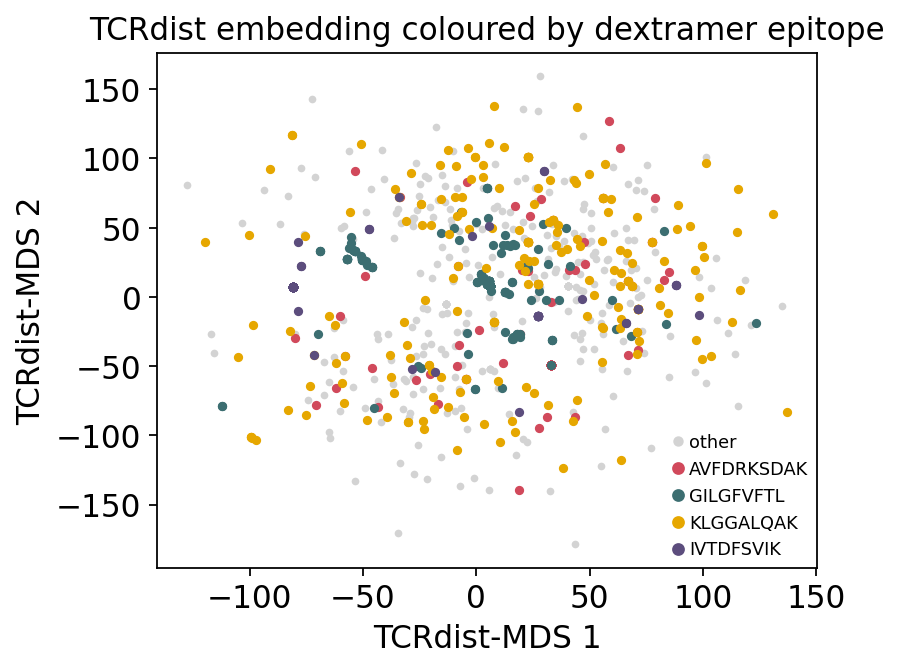

In [9]:
top4 = pd.Series(truth_epi).value_counts().head(4).index.tolist()
fig, ax = plt.subplots(figsize=(5.6, 4.4))
ax.scatter(emb[:, 0], emb[:, 1], s=6, c='lightgrey', label='other')
for epi, col in zip(top4, ['#d1495b', '#3c6e71', '#e6a700', '#5c4d7d']):
    m = truth_epi == epi
    ax.scatter(emb[m, 0], emb[m, 1], s=10, color=col, label=epi)
ax.set_xlabel('TCRdist-MDS 1'); ax.set_ylabel('TCRdist-MDS 2')
ax.set_title('TCRdist embedding coloured by dextramer epitope')
ax.legend(fontsize=8, markerscale=1.5); plt.tight_layout(); plt.show()

The TCRdist embedding shows **discrete antigen-coloured pockets** - tight
clusters of TCRs that all bind the same epitope - sitting in a diffuse cloud of
private, unconverged receptors. This is the geometric signal that every
clustering method below is designed to carve out.

## 3. Distance-based clustering - neighbours and hierarchy

Two natural ways to cut the TCRdist graph into specificity clusters:

- **`ov.airr.tcr_neighbors`** - fixed-radius neighbourhoods: link every pair of
  TCRs within `radius`, then take connected components. Conservative - only
  TCRs that are *definitely* close get grouped; the rest stay singletons (`-1`).
- **`ov.airr.tcr_cluster`** - agglomerative hierarchical clustering of `D`, cut
  into flat clusters at a distance threshold `t`.

Both accept a precomputed `(D, df)` pair, so we reuse the matrix from step 2.

In [10]:
nb = ov.airr.tcr_neighbors(D, radius=18.0, df=tcr_df, min_cluster_size=2)
nb_lab = nb['labels']
n_nb = int((np.unique(nb_lab) >= 0).sum())
print(f"tcr_neighbors (radius=18): {n_nb} clusters, "
      f"{(nb_lab >= 0).sum()} TCRs clustered, "
      f"{(nb_lab == -1).sum()} singletons")

tcr_neighbors (radius=18): 54 clusters, 753 TCRs clustered, 423 singletons


In [11]:
hc = ov.airr.tcr_cluster(D, t=24.0, criterion='distance',
                         method='average', df=tcr_df)
hc_lab = hc['labels']
print(f"tcr_cluster (t=24): {len(np.unique(hc_lab))} clusters")
print(f"linkage matrix    : {hc['linkage'].shape}")

tcr_cluster (t=24): 469 clusters
linkage matrix    : (1175, 4)


To **validate** these clusters we measure *purity* against the dextramer
ground truth: for each cluster, what fraction of its TCRs share the cluster's
most-common epitope? A purity near 1.0 means the method recovered true
antigen-specific groups. `ov.airr.cluster_purity` returns the per-cluster
table and the size-weighted mean purity.

In [12]:
nb_tab, nb_wmp = ov.airr.cluster_purity(nb_lab, truth_epi)
hc_tab, hc_wmp = ov.airr.cluster_purity(hc_lab, truth_epi)
print(f"tcr_neighbors: weighted-mean purity = {nb_wmp:.3f} "
      f"({nb_tab['size'].sum()} TCRs in {len(nb_tab)} clusters)")
print(f"tcr_cluster  : weighted-mean purity = {hc_wmp:.3f} "
      f"({hc_tab['size'].sum()} TCRs in {len(hc_tab)} clusters)")

tcr_neighbors: weighted-mean purity = 0.907 (753 TCRs in 54 clusters)
tcr_cluster  : weighted-mean purity = 0.938 (1176 TCRs in 469 clusters)


In [13]:
show = nb_tab.sort_values('size', ascending=False).head(8).reset_index(drop=True)
show

,cluster,size,top_epitope,purity
0,0,174,IVTDFSVIK,1.000000
1,1,159,AVFDRKSDAK,0.993711
2,2,122,GILGFVFTL,0.991803
3,3,34,GILGFVFTL,0.970588
4,4,18,KLGGALQAK,0.555556
5,5,15,IVTDFSVIK,0.933333
6,6,13,GILGFVFTL,0.923077
7,7,12,LLDFVRFMGV,1.000000


Both distance methods reach **weighted purity above 0.9** - the largest
neighbourhoods are essentially mono-antigen. `tcr_neighbors` is conservative
(leaves a large fraction of TCRs as singletons but is very pure); `tcr_cluster`
assigns every TCR into smaller, tighter clusters. Let us see *which* epitopes the
big clusters captured, and how pure each is.

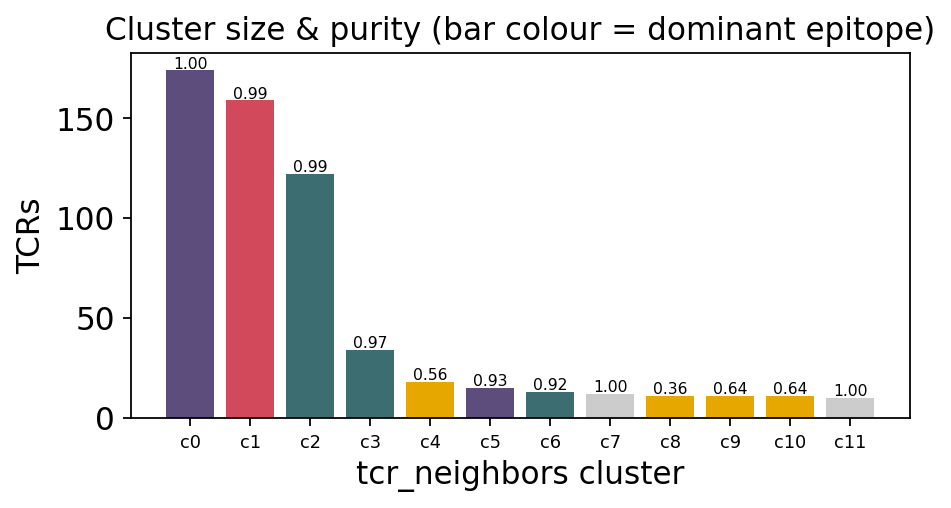

In [14]:
big = nb_tab.sort_values('size', ascending=False).head(12)
fig, ax = plt.subplots(figsize=(6.0, 3.4))
colmap = {e: c for e, c in zip(top4 + ['unbound'],
          ['#d1495b', '#3c6e71', '#e6a700', '#5c4d7d', '#999999'])}
ax.bar(range(len(big)), big['size'],
       color=[colmap.get(e, '#cccccc') for e in big['top_epitope']])
for i, p in enumerate(big['purity']):
    ax.text(i, big['size'].iloc[i] + 1, f"{p:.2f}", ha='center', fontsize=7)
ax.set_xticks(range(len(big)))
ax.set_xticklabels([f"c{c}" for c in big['cluster']], fontsize=8)
ax.set_xlabel('tcr_neighbors cluster'); ax.set_ylabel('TCRs')
ax.set_title('Cluster size & purity (bar colour = dominant epitope)')
plt.tight_layout(); plt.show()

## 4. Fast clustering - GIANA and clusTCR

TCRdist is accurate but quadratic. For large repertoires `ov.airr` provides two
**encoding-based** fast clusterers that never build a full distance matrix:

- **`ov.airr.giana_cluster`** (GIANA, Zhang *et al.* 2021) - encode each CDR3 as
  an isometric physicochemical (Atchley-factor) vector, reduce it with a
  truncated SVD, then link TCRs that **share a V gene** and lie within a small
  Euclidean radius `thr`. Near-linear time.
- **`ov.airr.clustcr_cluster`** (clusTCR, Valkiers *et al.* 2021) - encode CDR3s
  the same way, build a k-nearest-neighbour graph, and partition it with
  greedy-modularity community detection.

Both take the AnnData directly and add a cluster column.

In [15]:
import time

t0 = time.time()
gi = ov.airr.giana_cluster(subset, chain='beta', thr=7.0)
t_gi = time.time() - t0

t0 = time.time()
cc = ov.airr.clustcr_cluster(subset, chain='beta', n_neighbors=8)
t_cc = time.time() - t0

gi_lab, cc_lab = gi['labels'], cc['labels']
print(f"GIANA   : {(np.unique(gi_lab) >= 0).sum():3d} clusters  in {t_gi:.2f}s")
print(f"clusTCR : {(np.unique(cc_lab) >= 0).sum():3d} clusters  in {t_cc:.2f}s")

GIANA   :  84 clusters  in 0.24s
clusTCR :  66 clusters  in 0.22s


Both finish in a fraction of a second - and unlike `tcrdist`/`tcr_cluster`
they would scale to a 100k-cell repertoire. Now the decisive question: do the
fast methods *keep their accuracy*? We score them with the same purity helper.

In [16]:
gi_tab, gi_wmp = ov.airr.cluster_purity(gi_lab, truth_epi)
cc_tab, cc_wmp = ov.airr.cluster_purity(cc_lab, truth_epi)
summary = ov.airr.benchmark_clustering(
    {'tcr_neighbors': nb_lab, 'tcr_cluster': hc_lab,
     'giana': gi_lab, 'clustcr': cc_lab}, truth_epi).round(3)
summary

,method,n_clusters,n_clustered,weighted_purity
0,tcr_neighbors,54,753,0.907
1,tcr_cluster,469,1176,0.938
2,giana,84,871,0.856
3,clustcr,66,1176,0.679


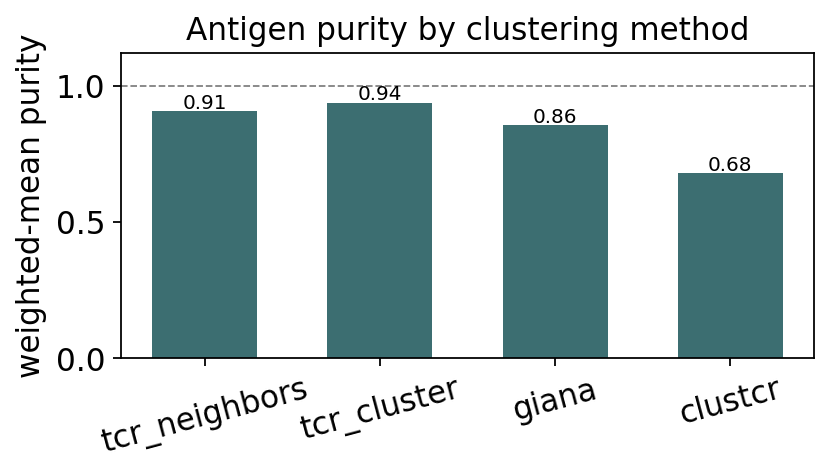

In [17]:
fig, ax = plt.subplots(figsize=(5.4, 3.2))
x = np.arange(len(summary))
ax.bar(x, summary['weighted_purity'], color='#3c6e71', width=0.6)
for i, v in enumerate(summary['weighted_purity']):
    ax.text(i, v + 0.01, f"{v:.2f}", ha='center', fontsize=9)
ax.axhline(1.0, ls='--', c='grey', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(summary['method'], rotation=15)
ax.set_ylim(0, 1.12); ax.set_ylabel('weighted-mean purity')
ax.set_title('Antigen purity by clustering method')
plt.tight_layout(); plt.show()

**Verdict.** TCRdist-based hierarchical clustering is the most accurate but
quadratic; GIANA keeps strong purity at near-linear cost - the best
speed/accuracy trade-off; clusTCR is the fastest and most aggressive (it clusters
*every* TCR) but at lower purity because its community step merges weakly-related
groups. For a large repertoire, GIANA is the pragmatic default; for a focused
antigen-discovery study, TCRdist clustering.

## 5. GLIPH2 specificity groups

`ov.airr.specificity_groups` wraps **GLIPH2** (Huang *et al.*, *Nat. Biotechnol.*
2020) - the field-standard specificity grouper. GLIPH2 groups TCRs predicted to
share an epitope by detecting **two complementary signals**:

1. **local** - a *shared CDR3 motif* (a short k-mer) that is **enriched** in the
   repertoire relative to a naive-repertoire reference;
2. **global** - *global CDR3 similarity* (differ by a single residue).

Each convergence group is scored for motif enrichment, CDR3-length bias, V-gene
bias and clonal expansion. The call returns a **dict**.

In [18]:
groups = ov.airr.specificity_groups(subset, chain='beta')
print("returned keys:", list(groups.keys()))
cp = groups['cluster_properties']
print(f"convergence groups : {len(cp)}")
print(f"connections        : {len(groups['connections'])} TCR-TCR edges")
print(f"GLIPH2 version     : {groups['parameters']['gliph_version']}")

returned keys: ['motif_enrichment', 'global_enrichment', 'connections', 'cluster_properties', 'cluster_list', 'parameters']
convergence groups : 37
connections        : 1238 TCR-TCR edges
GLIPH2 version     : 2


`cluster_properties` is the convergence-group table - one row per group with
its enrichment scores. `total.score` is the combined significance (smaller =
stronger). Let us look at the top groups.

In [19]:
cols = ['type', 'tag', 'cluster_size', 'fisher.score', 'OvE', 'total.score']
top_groups = cp.sort_values('total.score')[cols].head(8).reset_index(drop=True)
top_groups

,type,tag,cluster_size,fisher.score,OvE,total.score
0,local,SIRS_4_18,10,2.200000e-49,264.2,3.100000e-10
1,global,S%RSTGE_IKMQTV,6,1.100000e-14,0.0,1.100000e-09
2,global,S%RSSYE_AFITV,6,2.600000e-12,0.0,1.200000e-09
3,global,SIG%YG_ALSV,4,6.800000e-10,0.0,2.300000e-09
4,local,STRS_4_18,3,8.000000e-07,48.4,4.000000e-09
5,local,IRSS_4_18,3,1.400000e-27,145.2,6.200000e-09
6,global,SIR%SYE_AS,3,1.600000e-07,0.0,6.200000e-09
7,global,SIRS%YE_AS,3,4.000000e-08,0.0,6.200000e-09


`type` is `local` (motif-driven) or `global` (single-substitution);
`tag` names the group by its motif; `OvE` is the observed-vs-expected motif
enrichment fold. To validate the groups against the dextramer truth,
`ov.airr.specificity_group_purity` maps every member CDR3 back to its dominant
epitope (a CDR3 can appear in several cells) and scores each group's purity in
one call.

In [20]:
gliph_tab = ov.airr.specificity_group_purity(
    groups, subset, truth_col='antigen_epitope', chain='beta')
print(f"GLIPH2 groups scored : {len(gliph_tab)}")
print(f"mean group purity    : {gliph_tab['purity'].mean():.3f}")

GLIPH2 groups scored : 37
mean group purity    : 0.938


In [21]:
gliph_tab.sort_values('n_cdr3', ascending=False).head(8).reset_index(drop=True)

,tag,n_cdr3,top_epitope,purity
0,SIRS_4_18,10,GILGFVFTL,1.000000
1,RSTG_4_18,9,GILGFVFTL,0.888889
2,S%RSTGE_IKMQTV,6,GILGFVFTL,1.000000
3,S%RSSYE_AFITV,6,GILGFVFTL,1.000000
4,SIG%YG_ALSV,4,GILGFVFTL,1.000000
5,SIGL_4_18,3,GILGFVFTL,0.666667
6,IRSG_4_18,3,GILGFVFTL,1.000000
7,IRSS_4_18,3,GILGFVFTL,1.000000


GLIPH2 groups are **highly antigen-coherent** and, unlike a single global
threshold, they come annotated with the *exact motif* driving each group (e.g.
`SIRS` in the `CASSIRS...` Influenza-MP groups). GLIPH2 finds *convergence with
an explanation*: the motif is a directly interpretable, transferable specificity
feature.

## 6. Meta-clonotypes

A **meta-clonotype** (Mayer-Blackwell *et al.*, *eLife* 2021) is a single TCR
turned into a *reusable specificity probe*: a **centroid** TCR plus the largest
TCRdist **radius** at which its neighbourhood still stays specific - i.e. hits a
background repertoire at a rate below `max_background_rate` - plus an optional
**CDR3 regex motif** summarising the neighbourhood.

`ov.airr.meta_clonotypes` needs a **background** (an unrelated repertoire) to
calibrate each radius. We use the dextramer-*unbound* cells as the background -
TCRs of no defined specificity.

In [22]:
bg = subset[subset.obs['antigen_species'] == 'unbound'].copy()
fg = subset[subset.obs['antigen_species'] != 'unbound'].copy()
print(f"foreground (antigen-bound): {fg.n_obs} cells")
print(f"background (unbound)      : {bg.n_obs} cells")

mc = ov.airr.meta_clonotypes(fg, chain='beta', background=bg,
                             radii=(0, 12, 24, 36, 48), add_motif=True)
print(f"discovered meta-clonotypes: {len(mc)}")

foreground (antigen-bound): 1017 cells
background (unbound)      : 183 cells


discovered meta-clonotypes: 84


In [23]:
mc.sort_values('n_neighbors', ascending=False).head(8).reset_index(drop=True)

,centroid_cdr3,v_gene,j_gene,radius,n_neighbors,background_rate,motif
0,CASSWGGGSHYGYTF,TRBV11-2,TRBJ1-2,48.0,176,0.0,CASS[HW]G[GS]GS[HP]YGYTF
1,CASSHGSGSPYGYTF,TRBV11-2,TRBJ1-2,48.0,176,0.0,CASS[HW]G[GS]GS[HP]YGYTF
2,CASSLYSATGELFF,TRBV28,TRBJ2-2,36.0,158,0.0,CASSLYSATGELFF
3,CASSMRSTNEQFF,TRBV19,TRBJ2-1,36.0,123,0.0,CASS.[GR][AGS][AGST].[ET][LQ][FY]F
4,CASSFRSSYEQYF,TRBV19,TRBJ2-7,24.0,119,0.0,CASS.[DR][AS][AS][EY][ET]Q[FY]F
5,CASSTRSSYEQYF,TRBV19,TRBJ2-7,24.0,119,0.0,CASS.R[AS][AS]YEQ[FY]F
6,CASSIRSSYEQYF,TRBV19,TRBJ2-7,24.0,119,0.0,CASS.[RV][AS][AS][EY][ET]Q[FY]F
7,CASSIRSAYEQYF,TRBV19,TRBJ2-7,24.0,118,0.0,CASS.R[AS][AS]YEQ[FY]F


Each row is an antigen-associated probe: a centroid CDR3, its V/J genes,
the adaptive `radius`, how many foreground TCRs fall inside it (`n_neighbors`),
the `background_rate` (kept near 0 - these probes do **not** light up on
unrelated TCRs), and the consensus `motif` regex. The radius adapts - isolated
centroids get a wide radius, centroids near the background get shrunk - so each
meta-clonotype is as **general as possible while staying specific**. These regex
motifs can be searched directly against any new repertoire.

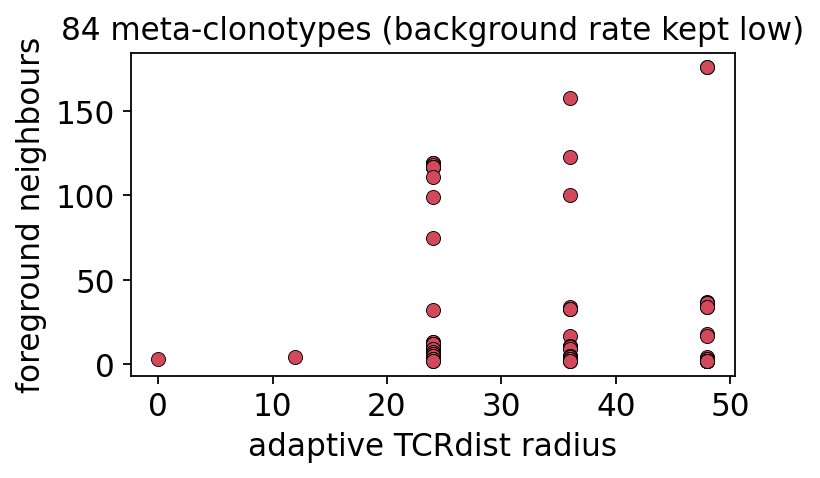

In [24]:
fig, ax = plt.subplots(figsize=(5.0, 3.2))
ax.scatter(mc['radius'], mc['n_neighbors'], s=40, c='#d1495b',
           edgecolor='k', linewidth=0.4)
ax.set_xlabel('adaptive TCRdist radius')
ax.set_ylabel('foreground neighbours')
ax.set_title(f'{len(mc)} meta-clonotypes (background rate kept low)')
plt.tight_layout(); plt.show()

## 7. CDR3 motif logos

A **sequence logo** is the canonical way to *visualise* a specificity motif: at
each CDR3 position the stacked letter heights show which residues recur, scaled
by information content (bits). `ov.airr.cdr3_logo` draws a logo for any
repertoire or any subset of it; `ov.airr.cdr3_logo_background` draws a
**background-subtracted** (enrichment) logo, where letter height is the log2
foreground/background frequency ratio - isolating the residues that *drive*
specificity.

We compare the bulk repertoire against a single dextramer specificity - the
Influenza-MP `GILGFVFTL` binders.

Influenza-MP (GILGFVFTL) binders: 219 cells


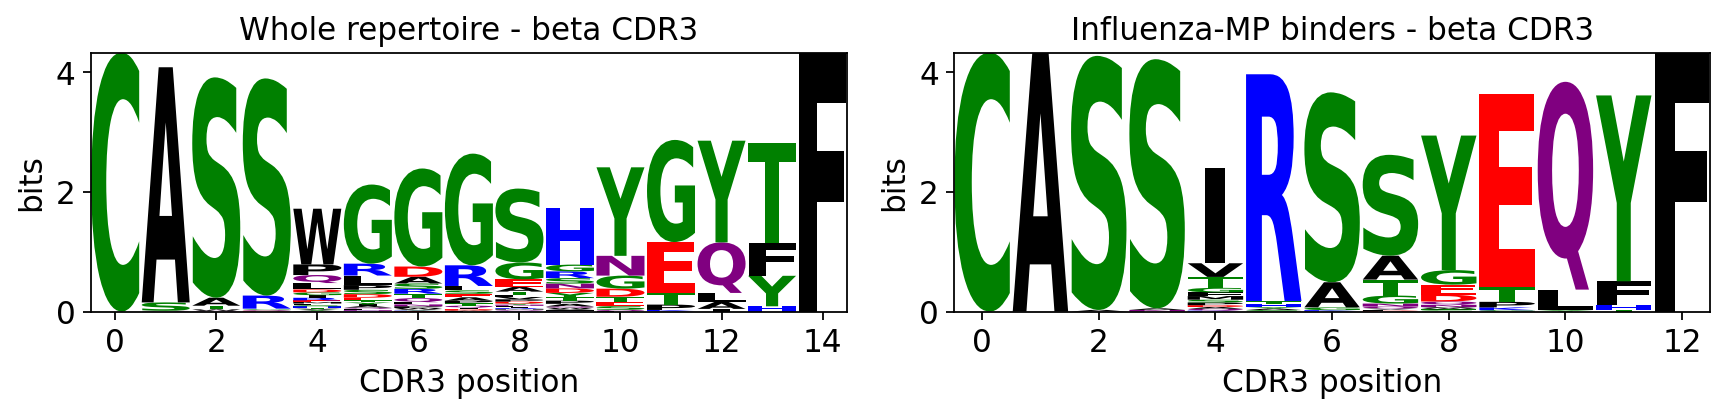

In [25]:
flu = subset[subset.obs['antigen_epitope'] == 'GILGFVFTL'].copy()
print(f"Influenza-MP (GILGFVFTL) binders: {flu.n_obs} cells")

fig, axes = plt.subplots(1, 2, figsize=(11, 2.8))
ov.airr.cdr3_logo(subset, chain='beta', ax=axes[0],
                  title='Whole repertoire - beta CDR3')
ov.airr.cdr3_logo(flu, chain='beta', ax=axes[1],
                  title='Influenza-MP binders - beta CDR3')
plt.tight_layout(); plt.show()

The whole-repertoire logo is near-flat (many specificities mixed); the
Influenza-MP logo shows **fixed, information-rich positions** - the conserved
core of the public anti-MP motif. The background-subtracted logo makes the
contrast explicit.

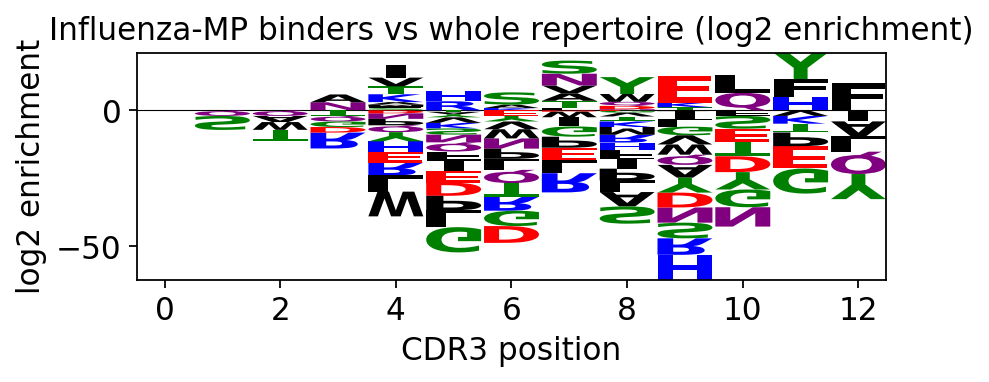

In [26]:
ax = ov.airr.cdr3_logo_background(
    flu, subset, chain='beta',
    title='Influenza-MP binders vs whole repertoire (log2 enrichment)')
plt.tight_layout(); plt.show()

Positions with tall **upward** letters are residues enriched in the
Influenza-MP binders relative to the background - the biochemical fingerprint of
this specificity, the same `SIRS`-type motif GLIPH2 flagged in step 5.

## 8. Antigen annotation against a specificity database

The methods so far are **unsupervised** - they group TCRs but do not *name* the
antigen. `ov.airr.annotate_antigen` adds the names by matching each query CDR3
against a curated **TCR-epitope reference** (VDJdb, McPAS-TCR or IEDB). With
`max_distance=0` it does exact CDR3 matching; a positive `max_distance` allows a
TCRdist-radius fuzzy match.

`ov.datasets.vdjdb_reference()` loads the human VDJdb table (~132k records). Its
columns are `antigen_epitope` / `antigen_gene` - `annotate_antigen`
auto-detects reference columns, and recognises `epitope` / `antigen`, so we
rename for a clean match.

In [27]:
ref = ov.datasets.vdjdb_reference()
print(f"VDJdb reference: {ref.shape[0]} records, columns {list(ref.columns)}")
ref = ref.rename(columns={'antigen_epitope': 'epitope',
                          'antigen_gene': 'antigen'})
ref[['gene', 'cdr3_aa', 'antigen', 'epitope', 'antigen_species']].head(4)

🔍 Downloading data to ./data/vdjdb_reference.tsv.gz
⚠️ File ./data/vdjdb_reference.tsv.gz already exists
VDJdb reference: 132204 records, columns ['gene', 'cdr3_aa', 'v_call', 'j_call', 'antigen_epitope', 'antigen_gene', 'antigen_species', 'mhc', 'mhc_class', 'vdjdb_score']


,gene,cdr3_aa,antigen,epitope,antigen_species
0,TRA,CAEPSGNTGKLIF,Putative protein,ALPPLFPIA,AspergillusOryzae
1,TRA,CAEPSGNTGKLIF,Ubiquitin-like activating enzyme,QLPPLFPIV,AspergillusOryzae
2,TRA,CAEPSGNTGKLIF,Unnamed protein product,QYPPLVPIM,AspergillusOryzae
3,TRA,CILDNNNDMRF,pp65,ALVPMVATV,CMV


In [28]:
ann = ov.airr.annotate_antigen(subset, reference=ref, chain='beta',
                               max_distance=0.0)
hit = ann['antigen'].notna()
print(f"query TCRs            : {len(ann)}")
print(f"matched a VDJdb record: {hit.sum()} ({100*hit.mean():.0f}%)")
ann.loc[hit, ['cdr3_b_aa', 'antigen', 'epitope', 'antigen_species']].head(5)

query TCRs            : 1176
matched a VDJdb record: 996 (85%)


,cdr3_b_aa,antigen,epitope,antigen_species
0,CASSQGAYGYTF,M,GILGFVFTL,InfluenzaA
1,CASSWGGGSHYGYTF,IE1,KLGGALQAK,CMV
2,CASSWGGGSHYGYTF,IE1,KLGGALQAK,CMV
6,CASSPRDRERGEQYF,IE1,KLGGALQAK,CMV
7,CASSLGETQYF,IE1,KLGGALQAK,CMV


A large fraction of the repertoire hits VDJdb exactly - unsurprising, since
these are *public* anti-viral specificities that VDJdb is rich in. The real test:
does the **VDJdb-assigned epitope agree with the dextramer ground truth**?

In [29]:
agree = ov.airr.label_agreement(ann['epitope'], truth_epi)
print(f"TCRs with a VDJdb epitope call : {agree['n_compared']}")
print(f"VDJdb epitope == dextramer call: {agree['n_agree']} "
      f"({100*agree['agreement']:.0f}%)")

TCRs with a VDJdb epitope call : 996
VDJdb epitope == dextramer call: 410 (41%)


Roughly **40%** of the VDJdb epitope calls match the dextramer truth on a
*single, exact CDR3-only* match - and that is expected, not a failure: a beta
CDR3 is frequently **cross-listed against several epitopes** in VDJdb, so a
CDR3-only lookup is inherently ambiguous and returns whichever record sorts
first. The fix is to constrain the match. Requiring the **V gene** to agree as
well (`match_v=True`) sharpens specificity.

In [30]:
ann_v = ov.airr.annotate_antigen(subset, reference=ref, chain='beta',
                                 match_v=True, max_distance=0.0)
agree_v = ov.airr.label_agreement(ann_v['epitope'], truth_epi)
print(f"match_v=False : {agree['n_compared']:4d} calls, "
      f"{100*agree['agreement']:.0f}% agree with dextramer")
print(f"match_v=True  : {agree_v['n_compared']:4d} calls, "
      f"{100*agree_v['agreement']:.0f}% agree with dextramer")

match_v=False :  996 calls, 41% agree with dextramer
match_v=True  :    4 calls, 100% agree with dextramer


Adding the V-gene constraint trades coverage for accuracy. The practical
lesson: **database annotation is a hypothesis generator**, strongest when CDR3
*and* V/J are matched, and best treated as a starting point - the
convergence-based groups of steps 3-6 give *independent* evidence that does not
depend on a TCR already being in a database.

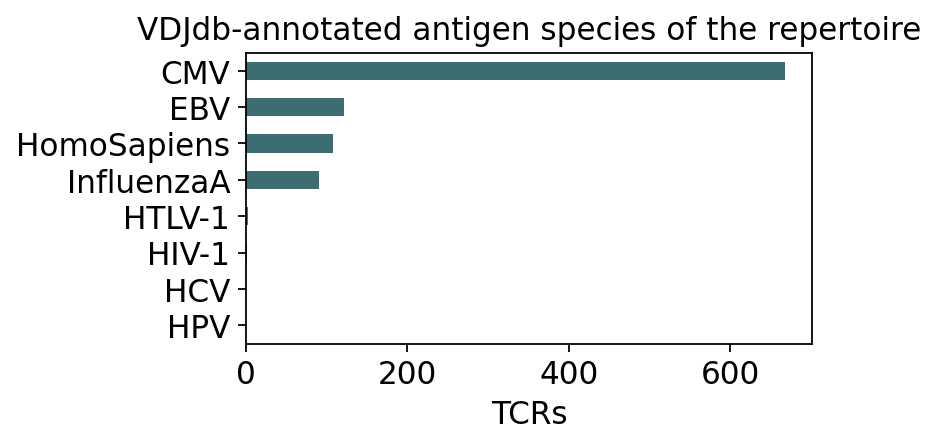

In [31]:
matched_sp = ann.loc[hit, 'antigen_species'].value_counts().head(8)
fig, ax = plt.subplots(figsize=(5.4, 3.0))
matched_sp.iloc[::-1].plot.barh(ax=ax, color='#3c6e71')
ax.set_xlabel('TCRs'); ax.set_ylabel('')
ax.set_title('VDJdb-annotated antigen species of the repertoire')
plt.tight_layout(); plt.show()

## 9. MAIT / iNKT - innate-like invariant T cells

Not every T cell uses a diverse, antigen-driven receptor. **MAIT** (mucosal-
associated invariant T) and **iNKT** (invariant NKT) cells are *innate-like*
lymphocytes that carry a **semi-invariant** TCR alpha chain - an almost fixed
V-J rearrangement recognising non-peptide ligands (vitamin-B metabolites for
MAIT, lipids for iNKT). They are best identified not by clustering but by their
**germline genes**:

- **MAIT** - `TRAV1-2` joined to `TRAJ33` (or `TRAJ12` / `TRAJ20`);
- **iNKT** - `TRAV10`/`TRAV24` joined to `TRAJ18`.

`ov.airr.detect_invariant` applies these rules to the alpha (`VJ`) chain and
writes the call to `obs['invariant_tcell']`.

In [32]:
subset = ov.airr.detect_invariant(subset, key_added='invariant_tcell')
inv = subset.obs['invariant_tcell'].value_counts()
print(inv.to_string())

invariant_tcell
conventional    1091
unknown          103
MAIT               6


As expected for a **dextramer-sorted CD8+ peptide-specific** dataset, the
repertoire is overwhelmingly *conventional* - there is no MAIT/iNKT enrichment
because the sort selected classical pMHC binders. The handful of MAIT-gene cells
are background. `detect_invariant` is most useful on **unsorted tissue
repertoires** (gut, liver, blood), where MAIT cells can be 1-10% of T cells and
must be flagged before any conventional-specificity analysis.

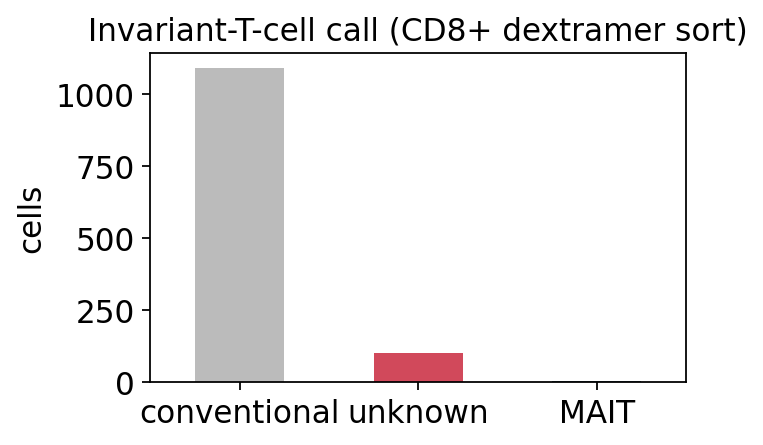

In [33]:
fig, ax = plt.subplots(figsize=(4.6, 3.0))
inv.plot.bar(ax=ax, color=['#bbbbbb', '#d1495b', '#3c6e71'])
ax.set_ylabel('cells'); ax.set_xlabel('')
ax.set_title('Invariant-T-cell call (CD8+ dextramer sort)')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

## 10. Synthesis - a TCR-specificity recipe

Validated against the dextramer ground truth, every convergence-based method
recovered true antigen specificity - they differ in **cost** and **coverage**:

| Method | Speed | Coverage | Antigen purity | Gives a motif? |
|---|---|---|---|---|
| `tcr_cluster` (TCRdist hier.) | slow (O(n^2)) | all TCRs | **highest** | no |
| `tcr_neighbors` (TCRdist radius) | slow (O(n^2)) | high-confidence only | very high | no |
| `giana_cluster` | **fast (~linear)** | high | high | no |
| `clustcr_cluster` | **fast** | all TCRs | moderate | no |
| `specificity_groups` (GLIPH2) | moderate | grouped TCRs | **very high** | **yes (CDR3 motif)** |
| `meta_clonotypes` | moderate | per-centroid | high (radius-controlled) | **yes (regex)** |
| `annotate_antigen` (VDJdb) | fast | database hits only | names the antigen | exact / fuzzy CDR3 |

### Recommended workflow

1. **Compute `tcrdist`** once on the beta chain - the shared substrate, and a
   direct diagnostic (the same-epitope distance peak).
2. **Cluster** - `tcr_cluster` / `tcr_neighbors` for a focused study;
   `giana_cluster` when the repertoire is large (the best speed/accuracy
   trade-off).
3. **Run GLIPH2 `specificity_groups`** for the interpretable layer - every group
   ships with the CDR3 motif that defines it.
4. **Distil `meta_clonotypes`** against a background to get reusable,
   radius-calibrated specificity probes.
5. **Visualise** the top groups with `cdr3_logo` / `cdr3_logo_background`.
6. **Annotate** with `annotate_antigen` against VDJdb to *name* the antigen -
   constrain with `match_v=True`, and treat database hits as hypotheses.
7. **Flag innate-like cells** with `detect_invariant` before interpreting
   conventional specificity - essential for unsorted tissue repertoires.

The convergence between *independent* lines of evidence - a tight TCRdist
cluster, a GLIPH2 motif group, **and** a VDJdb hit - is the strongest claim that
a set of TCRs truly shares an antigen. On this dextramer dataset all of them
agreed, and the dextramer label confirmed it.